Q:1 Read research papers on following Convolutional Neural Networks and Summarise the salient feature of Each Architecture:
- AlexNet
- Resnet
- InceptionNet
- EfficientNet



**AlexNet**:
AlexNet is the name of a convolutional neural network (CNN) architecture, designed by Alex Krizhevsky in collaboration with Ilya Sutskever and Geoffrey Hinton.
AlexNet contained eight layers; the first five were convolutional layers, some of them followed by max-pooling layers, and the last three were fully connected layers. It used the non-saturating ReLU activation function, which showed improved training performance over tanh and sigmoid.


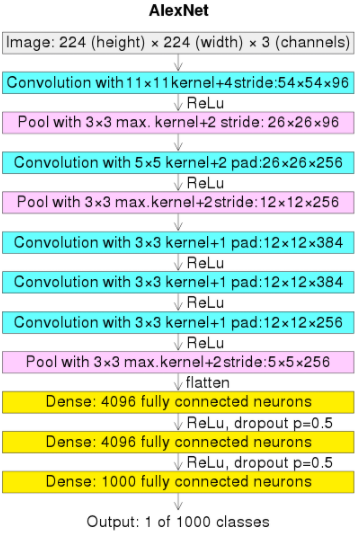

It reduces overfitting by applying Data Augmentation and Dropout.


**Resnet**:
**Residual Network (ResNet)** is one of the famous deep learning models that was introduced by Shaoqing Ren, Kaiming He, Jian Sun, and Xiangyu Zhang in their paper named “Deep Residual Learning for Image Recognition” in 2015. ResNet model is made up of these blocks. There is a 34-layer plain network in the architecture that is inspired by VGG-19 in which the shortcut connection or the skip connections are added. These skip connections or the residual blocks then convert the architecture into the residual network.

A residual block works as follows:

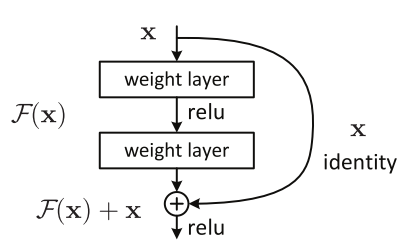


The ResNet Architecture works with following steps:

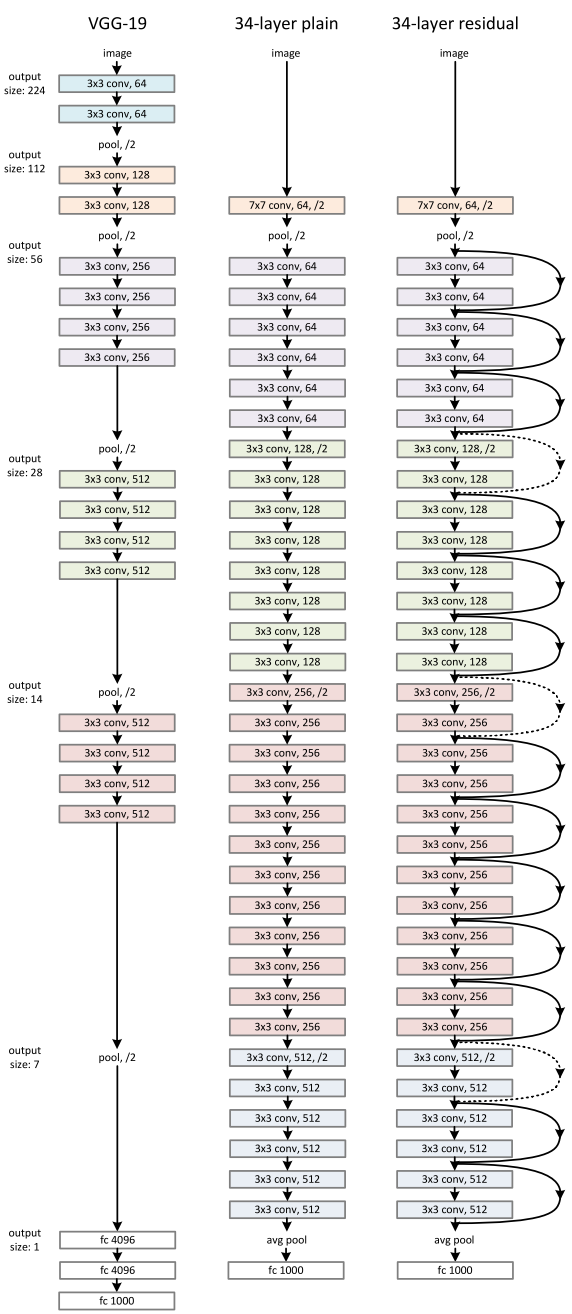



**InceptionNet**:

Inception net achieved a milestone in CNN classifiers when previous models were just going deeper to improve the performance and accuracy but compromising the computational cost. The Inception network, on the other hand, is heavily engineered. It uses a lot of tricks to push performance, both in terms of speed and accuracy.

The most popular versions are:
*   Inception v1
*   Inception v2 and Inception v3
*   Inception v4 and Inception-ResNet

The base version of the Inception module as follows:

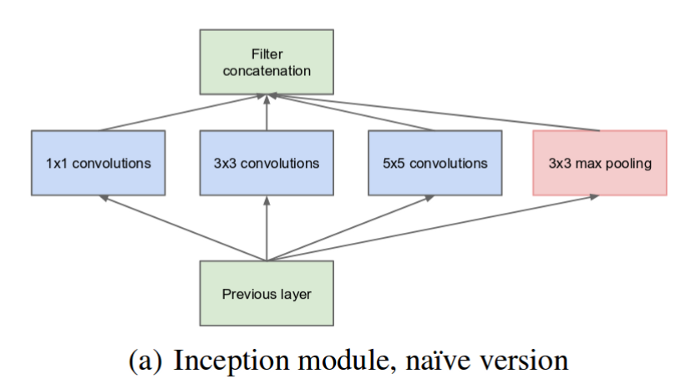

Deep neural networks are computationally expensive. To make it cheaper, the authors limit the number of input channels by adding an extra 1x1 convolution before the 3x3 and 5x5 convolutions. Though adding an extra operation may seem counterintuitive, 1x1 convolutions are far more cheaper than 5x5 convolutions, and the reduced number of input channels also help. Do note that however, the 1x1 convolution is introduced after the max pooling layer, rather than before.

After reducing the dimension it works as follows:

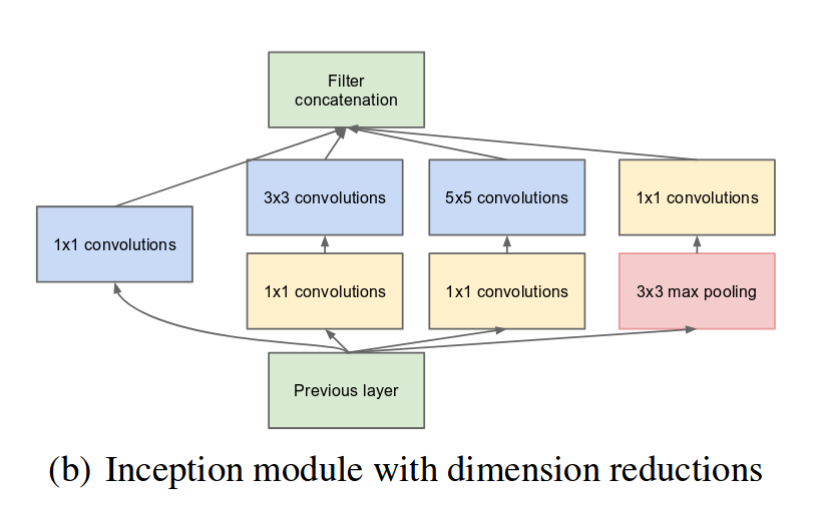

Using the dimension reduced inception module, a neural network architecture was built. This was popularly known as GoogLeNet (Inception v1). The architecture is shown below:

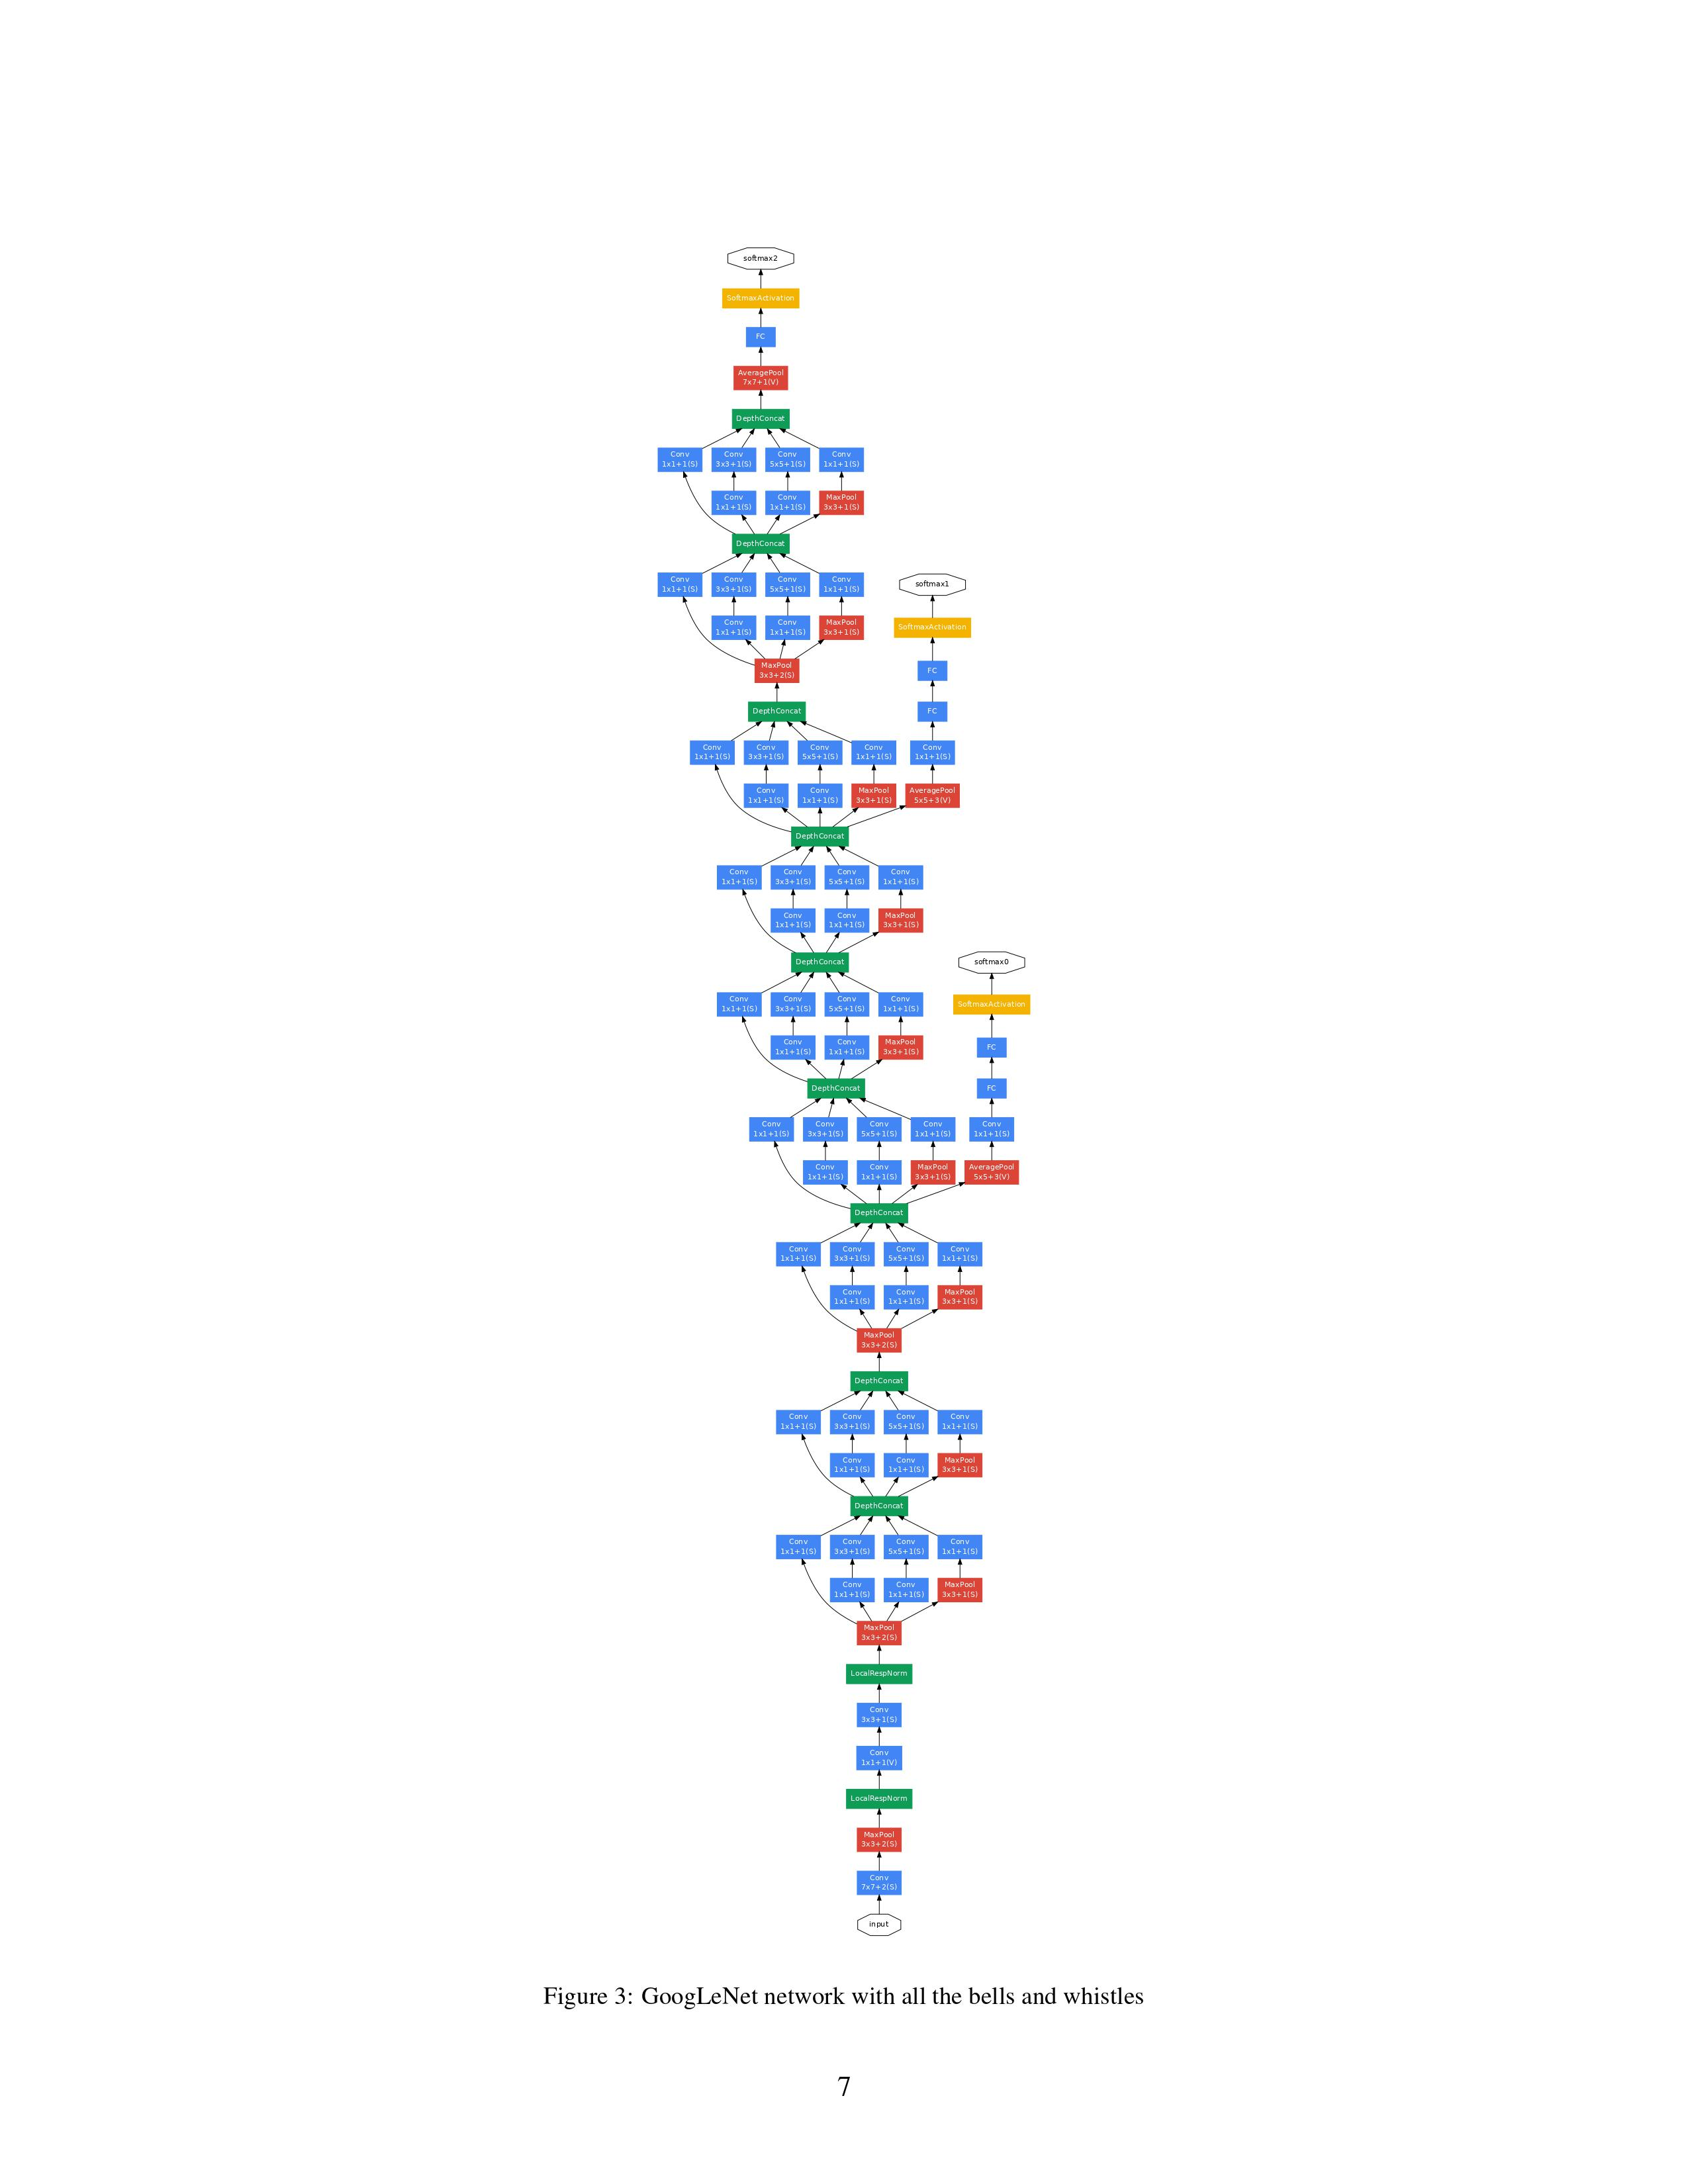

GoogLeNet has 9 such inception modules stacked linearly. It is 22 layers deep (27, including the pooling layers). It uses global average pooling at the end of the last inception module.
Needless to say, it is a pretty deep classifier. As with any very deep network, it is subject to the vanishing gradient problem.
To prevent the middle part of the network from “dying out”, the authors introduced two auxiliary classifiers (The purple boxes in the image). They essentially applied softmax to the outputs of two of the inception modules, and computed an auxiliary loss over the same labels. The total loss function is a weighted sum of the auxiliary loss and the real loss. Weight value used in the paper was 0.3 for each auxiliary loss.







**EfficientNet**

EfficientNet is a convolutional neural network architecture and scaling method that uniformly scales all dimensions of depth/width/resolution using a compound coefficient.

In “EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks”, authors proposed a novel model scaling method that uses a simple yet highly effective compound coefficient to scale up CNNs in a more structured manner. Unlike conventional approaches that arbitrarily scale network dimensions, such as width, depth and resolution, this method uniformly scales each dimension with a fixed set of scaling coefficients. Powered by this novel scaling method and recent progress on AutoML, they developed a family of models, called EfficientNets, which superpass state-of-the-art accuracy with up to 10x better efficiency (smaller and faster).

Unlike conventional practice that arbitrary scales these factors, the EfficientNet scaling method uniformly scales network width, depth, and resolution with a set of fixed scaling coefficients. For example, if we want to use 2^N times more computational resources, then we can simply increase the network depth by \alpha ^ N, width by \beta ^ N, and image size by \gamma ^ N, where \alpha, \beta, \gamma are constant coefficients determined by a small grid search on the original small model. EfficientNet uses a compound coefficient  to uniformly scales network width, depth, and resolution in a principled way.

The compound scaling method is justified by the intuition that if the input image is bigger, then the network needs more layers to increase the receptive field and more channels to capture more fine-grained patterns on the bigger image.

The base EfficientNet-B0 network is based on the inverted bottleneck residual blocks of MobileNetV2, in addition to squeeze-and-excitation blocks.

EfficientNets also transfer well and achieve state-of-the-art accuracy on CIFAR-100 (91.7%), Flowers (98.8%), and 3 other transfer learning datasets, with an order of magnitude fewer parameters.

The first step in the compound scaling method is to perform a grid search to find the relationship between different scaling dimensions of the baseline network under a fixed resource constraint (e.g., 2x more FLOPS).This determines the appropriate scaling coefficient for each of the dimensions mentioned above. We then apply those coefficients to scale up the baseline network to the desired target model size or computational budget.

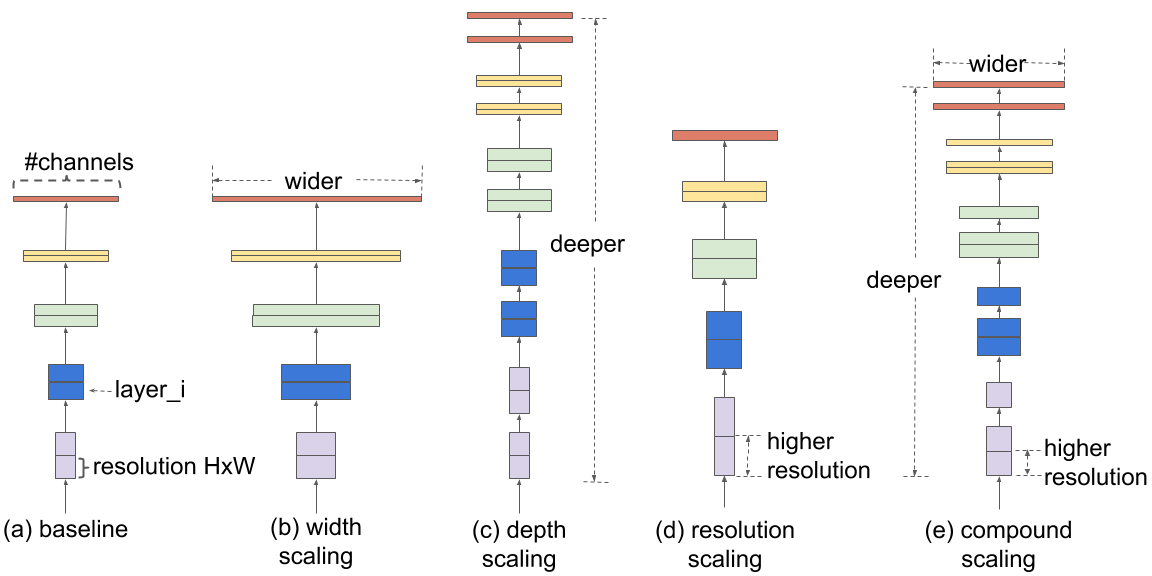


This compound scaling method consistently improves model accuracy and efficiency for scaling up existing models such as MobileNet (+1.4% imagenet accuracy), and ResNet (+0.7%), compared to conventional scaling methods.

EfficientNet Architecture
The effectiveness of model scaling also relies heavily on the baseline network. So, to further improve performance, authors have also developed a new baseline network by performing a neural architecture search using the AutoML MNAS framework, which optimizes both accuracy and efficiency (FLOPS). The resulting architecture uses mobile inverted bottleneck convolution (MBConv), similar to MobileNetV2 and MnasNet, but is slightly larger due to an increased FLOP budget. Then it was scaled up the baseline network to obtain a family of models, called EfficientNets.

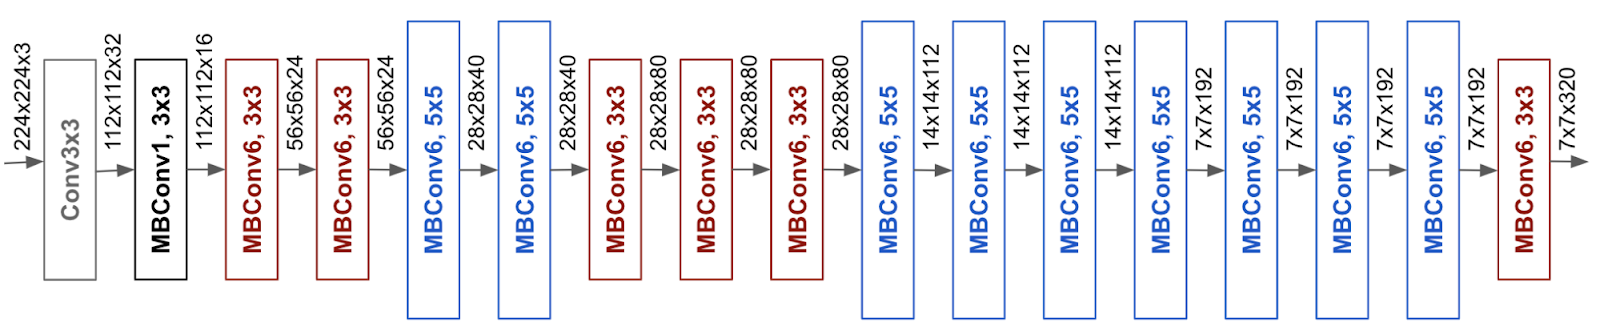




Q2: Build your own VGGNet from Scratch and Train the model on CatsAndDogs Dataset

In [ ]:
from keras.layers import Input, Lambda, Dense, Flatten,Dropout
from keras.models import Model

from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import tensorflow as tf
import os
import matplotlib.pyplot as plt
import numpy as np


_URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
path_to_zip = tf.keras.utils.get_file('cats_and_dogs.zip', origin=_URL, extract=True)
PATH = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')

os.mkdir("CatsAndDogs")

68616192/68606236 [==============================] - 0s 0us/step


In [ ]:
# importing shutil module 
import shutil 
  
# Source path 
src = PATH
    
# Destination path 
dest = 'CatsAndDogs/Dataset'
    
# Copy the content of 
# source to destination 
destination = shutil.copytree(src, dest) 

In [ ]:
ls CatsAndDogs/Dataset

train/  validation/  vectorize.py


In [ ]:
ls CatsAndDogs/Dataset/train

cats/  dogs/


In [ ]:
BATCH_SIZE = 32
IMG_SIZE = [160, 160]

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

train_dir = 'CatsAndDogs/Dataset/train'
validation_dir = 'CatsAndDogs/Dataset/validation'


train_dataset = image_dataset_from_directory(train_dir,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE)

validation_dataset = image_dataset_from_directory(validation_dir,
                                                  shuffle=True,
                                                  batch_size=BATCH_SIZE,
                                                  image_size=IMG_SIZE)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [ ]:
# Verifying the shape of Batch
image_batch, label_batch = next(iter(train_dataset))
print(image_batch.shape)
print(label_batch.shape)

(32, 160, 160, 3)
(32,)


In [ ]:
class_names = train_dataset.class_names
class_names

['cats', 'dogs']

Plotting some images

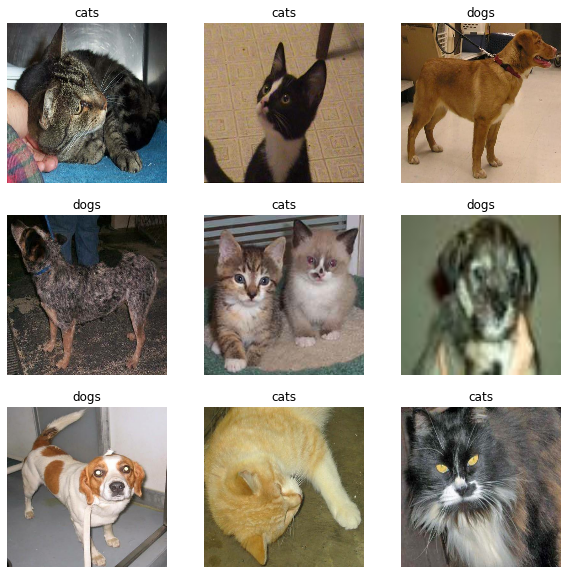

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

Loading the Pretrained model and freeze the convolutional base

In [ ]:
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input

# Load pretrained VGG16 Model
vgg = VGG16(input_shape=IMG_SIZE + [3], weights='imagenet', include_top=False)

# don't train existing weights
for layer in vgg.layers:
  layer.trainable = False

58900480/58889256 [==============================] - 0s 0us/step


In [ ]:
vgg.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 160, 160, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 160, 160, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 80, 80, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 80, 80, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 80, 80, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 40, 40, 128)       0     

### Add Linear Layers for Finetuning:
- Finally we will create a trainable DNN i.e top of the model and add it to our PreTrained model.

In [ ]:
x = Flatten()(vgg.output)
x = Dense(4096, activation = 'relu')(x)
x = Dense(4096, activation = 'relu')(x)
x = Dropout(0.5)(x)

In [ ]:
### Note: Change the number of Neuron to Number of classes and activation to softmax for mutliclass Classifcation
prediction = Dense(1, activation='sigmoid')(x)

model = Model(inputs=vgg.input, outputs=prediction)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 160, 160, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 160, 160, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 80, 80, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 80, 80, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 80, 80, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 40, 40, 128)       0     

### Compile the Model:
- Now we will Compile the model before training it. Since there are two classes, use a binary cross-entropy loss.
- If we had multiple classes then Categorical Crossentropy would be the loss function.

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compiling model with Optimizer and Loss --------------------------------> Change loss to Categorical Crossentropy for multiclass
model.compile(optimizer = 'Adam', loss='binary_crossentropy',metrics = ['accuracy'])

In [ ]:
model.fit(train_dataset, validation_data=validation_dataset, batch_size=BATCH_SIZE, epochs=10, verbose=1)

Epoch 1/10
63/63 [==============================] - 833s 13s/step - loss: 23.3205 - accuracy: 0.8735 - val_loss: 0.2900 - val_accuracy: 0.9540
Epoch 2/10
63/63 [==============================] - 873s 14s/step - loss: 0.1755 - accuracy: 0.9735 - val_loss: 0.7809 - val_accuracy: 0.9030
Epoch 3/10
63/63 [==============================] - 815s 13s/step - loss: 0.0879 - accuracy: 0.9885 - val_loss: 0.4277 - val_accuracy: 0.9480
Epoch 4/10
63/63 [==============================] - 812s 13s/step - loss: 0.0669 - accuracy: 0.9895 - val_loss: 1.0494 - val_accuracy: 0.9290
Epoch 5/10
10/63 [===>..........................] - ETA: 7:49 - loss: 0.0623 - accuracy: 0.9937

In [ ]:
history = model.history


import matplotlib.pyplot as plt

# list all data in history
print(history.history.keys())

# plot history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# plot history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

AttributeError: ignored

Q3: For the same dataset as above, experiment with ResNET50, EfficientNetB3 and Alexnet. Do comparison Analysis of performance.

# **ResNET50**

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np


In [ ]:
resnet = ResNet50( input_shape=IMG_SIZE+[3], include_top=False, weights="imagenet")

94781440/94765736 [==============================] - 1s 0us/step


In [ ]:
for layer in resnet.layers:
  layer.trainable = False

In [ ]:
resnet.summary()

# FineTuning

In [ ]:
xResnet = Flatten()(resnet.output)
xResnet = Dense(4096, activation = 'relu')(xResnet)
xResnet = Dense(4096, activation = 'relu')(xResnet)
xResnet = Dropout(0.5)(xResnet)

In [ ]:
### Note: Change the number of Neuron to Number of classes and activation to softmax for mutliclass Classifcation
predictionResnet = Dense(1, activation='softmax')(xResnet)

modelResnet = Model(inputs=resnet.input, outputs=predictionResnet)
modelResnet.summary()

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compiling model with Optimizer and Loss --------------------------------> Change loss to Categorical Crossentropy for multiclass
modelResnet.compile(optimizer = 'Adam', loss='binary_crossentropy',metrics = ['accuracy'])

In [ ]:
train_datasetResnet = image_dataset_from_directory(train_dir,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE)

validation_datasetResnet = image_dataset_from_directory(validation_dir,
                                                  shuffle=True,
                                                  batch_size=BATCH_SIZE,
                                                  image_size=IMG_SIZE)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [ ]:
type(train_datasetResnet)

tensorflow.python.data.ops.dataset_ops.BatchDataset

In [ ]:
#modelResnet.fit(train_dataset, validation_data=validation_dataset, epochs=5, verbose=1)
modelResnet.fit(train_datasetResnet, validation_data=validation_datasetResnet, batch_size=BATCH_SIZE, epochs=10, verbose=1)

63/63 [==============================] - 230s 4s/step - loss: 11.3968 - accuracy: 0.5000 - val_loss: 0.1988 - val_accuracy: 0.5000


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


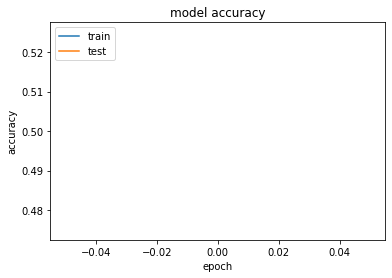

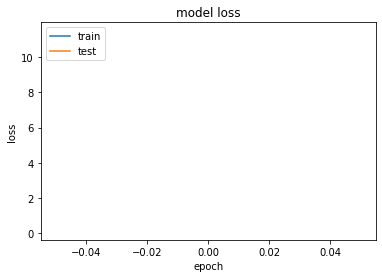

In [ ]:
historyResnet = modelResnet.history


import matplotlib.pyplot as plt

# list all data in history
print(historyResnet.history.keys())

# plot history for accuracy
plt.plot(historyResnet.history['accuracy'])
plt.plot(historyResnet.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# plot history for loss
plt.plot(historyResnet.history['loss'])
plt.plot(historyResnet.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# **EfficientNetB3**

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Epoch 1/5
63/63 [==============================] - 244s 4s/step - loss: 1.2025 - accuracy: 0.5000 - val_loss: 0.3785 - val_accuracy: 0.5000
Epoch 2/5
63/63 [==============================] - 224s 4s/step - loss: 0.1823 - accuracy: 0.5000 - val_loss: 0.4293 - val_accuracy: 0.5000
Epoch 3/5
63/63 [==============================] - 228s 4s/step - loss: 0.1082 - accuracy: 0.5000 - val_loss: 0.1418 - val_accuracy: 0.5000
Epoch 4/5
63/63 [==============================] - 232s 4s/step - loss: 0.0403 - accuracy: 0.5000 - val_loss: 0.1625 - val_accuracy: 0.5000
Epoch 5/5
63/63 [==============================] - 236s 4s/step - loss: 0.0677 - accuracy: 0.5000 - val_loss: 0.2778 - val_accuracy: 0.5000
dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


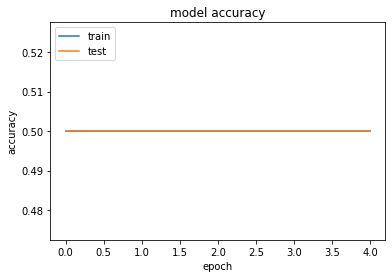

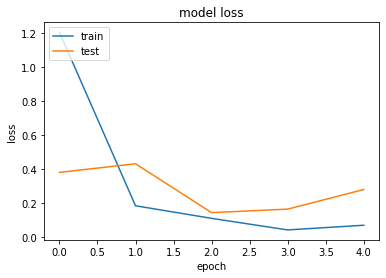

In [ ]:
from tensorflow.keras.applications.efficientnet import EfficientNetB3
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input, decode_predictions
import numpy as np

BATCH_SIZE_EFFICIENTNET = 32
IMG_SIZE_EFFICIENTNET = [160, 160]

efficient_net = EfficientNetB3(input_shape=IMG_SIZE_EFFICIENTNET+[3], include_top=False, weights="imagenet")

for layer in efficient_net.layers:
  layer.trainable = False

#efficient_net.summary()

xEfficientNet = Flatten()(efficient_net.output)
xEfficientNet = Dense(4096, activation = 'relu')(xEfficientNet)
xEfficientNet = Dense(4096, activation = 'relu')(xEfficientNet)
xEfficientNet = Dropout(0.5)(xEfficientNet)

predictionEfficientNet = Dense(1, activation='softmax')(xEfficientNet)

modelEfficientNet = Model(inputs=efficient_net.input, outputs=predictionEfficientNet)
#modelEfficientNet.summary()

from tensorflow.keras.optimizers import Adam

# Compiling model with Optimizer and Loss --------------------------------> Change loss to Categorical Crossentropy for multiclass
modelEfficientNet.compile(optimizer = 'Adam', loss='binary_crossentropy',metrics = ['accuracy'])

train_datasetEfficientNet = image_dataset_from_directory(train_dir,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE_EFFICIENTNET,
                                             image_size=IMG_SIZE_EFFICIENTNET)

validation_datasetEfficientNet = image_dataset_from_directory(validation_dir,
                                                  shuffle=True,
                                                  batch_size=BATCH_SIZE_EFFICIENTNET,
                                                  image_size=IMG_SIZE_EFFICIENTNET)

modelEfficientNet.fit(train_datasetEfficientNet, validation_data=validation_datasetEfficientNet, batch_size=BATCH_SIZE_EFFICIENTNET, epochs=10, verbose=1)

historyEfficientNet = modelEfficientNet.history


import matplotlib.pyplot as plt

# list all data in history
print(historyEfficientNet.history.keys())

# plot history for accuracy
plt.plot(historyEfficientNet.history['accuracy'])
plt.plot(historyEfficientNet.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# plot history for loss
plt.plot(historyEfficientNet.history['loss'])
plt.plot(historyEfficientNet.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# **Alexnet**

https://analyticsindiamag.com/implementing-alexnet-using-pytorch-as-a-transfer-learning-model-in-multi-class-classification/

https://analyticsindiamag.com/hands-on-guide-to-implementing-alexnet-with-keras-for-multi-class-image-classification/

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

Here, we are defining an object through which we can transform an image into the required image dataset that will be compatible with the AlexNet model. Using the below code snippet, the input image will be first converted to the size 256×256 pixels and then cropped to the size 224×224 pixels as the AlexNet model require the input images with size 224×224. Finally, the image dataset will be converted to the PyTorch tensor data type. To normalize the input image data set, the mean and standard deviation of the pixels data is used as per the standard values suggested by the PyTorch.

In [ ]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
BATCH_SIZE_ALEXNET = 32
IMG_SIZE_ALEXNET = [160, 160]

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

train_dir = 'CatsAndDogs/Dataset/train'
validation_dir = 'CatsAndDogs/Dataset/validation'

'''
train_dataset_AlexNet =image_dataset_from_directory(train_dir,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE_ALEXNET,
                                             image_size=IMG_SIZE_ALEXNET)
'''
train_dataset_AlexNet = torchvision.datasets.ImageFolder(train_dir, transform=transform)

trainloader = torch.utils.data.DataLoader(train_dataset_AlexNet, batch_size=4, shuffle=True, num_workers=2)

'''
test_dataset_AlexNet = image_dataset_from_directory(validation_dir,
                                                  shuffle=True,
                                                  batch_size=BATCH_SIZE_ALEXNET,
                                                  image_size=IMG_SIZE_ALEXNET)
'''                                              
test_dataset_AlexNet = torchvision.datasets.ImageFolder(validation_dir, transform=transform)

testloader = torch.utils.data.DataLoader(test_dataset_AlexNet, batch_size=4, shuffle=False, num_workers=2)


In [ ]:
classes = train_dataset_AlexNet.classes

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#Function to show some random images
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

#Get some random training images
dataiter = iter(trainloader)
type(dataiter)

torch.utils.data.dataloader._MultiProcessingDataLoaderIter

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


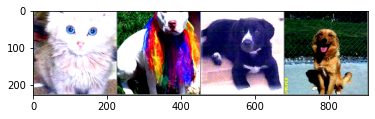

 cats  dogs  dogs  dogs


In [ ]:
images, labels = dataiter.next()

#Show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

In [ ]:
#Now using the AlexNet
modelAlexNet = models.alexnet(pretrained=True)

#Model description
modelAlexNet.eval()

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


  0%|          | 0.00/233M [00:00<?, ?B/s]

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
#Updating the second classifier
modelAlexNet.classifier[4] = torch.nn.Linear(4096,1024)

#Updating the third and the last classifier that is the output layer of the network. Make sure to have 10 output nodes if we are going to get 10 class labels through our model.
modelAlexNet.classifier[6] = torch.nn.Linear(1024,10)

#Once updated, we will gain check the description of the model
modelAlexNet.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
#Instantiating CUDA device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

#Verifying CUDA
print(device)

#Move the input and AlexNet_model to GPU for speed if available
modelAlexNet.to(device)

cpu


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
import torch.optim as optim
import torch.nn as nn

#Loss
criterion = nn.CrossEntropyLoss()

#Optimizer(SGD)
optimizer = optim.SGD(modelAlexNet.parameters(), lr=0.001, momentum=0.9)

In [ ]:
#In the next step, we will train the AlexNet model using the below code snippet.
for epoch in range(10):  # loop over the dataset multiple times
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data[0].to(device), data[1].to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        output = modelAlexNet(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training of AlexNet')

/usr/local/lib/python3.7/dist-packages/torch/nn/functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  /pytorch/c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


Finished Training of AlexNet


In [ ]:
#Testing Accuracy
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = modelAlexNet(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 95 %


In [ ]:
#Testing classification accuracy for individual classes.
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = modelAlexNet(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

for i in range(len(classes)):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of  cats : 95 %
Accuracy of  dogs : 96 %


Q4: Collect images of 5 objects from your daily life, (Atleast50 Images per Class). Build a CNN from scratch for classfying these objects.

Q5 : Use Transfer Learning and build CNN for dataset collected in previous Step using Resnet50 architecture and do a comparison analysis based on Training time as well as performance.